# 08 — Model Comparison: Faster R-CNN + Fuzzy Logic vs YOLOv8

Evaluates and compares both approaches on the same test images using IoU, precision, recall, mAP, and inference speed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/ROI_Endoscopy_Paper')
print('Working directory:', os.getcwd())

Working directory: /content/drive/MyDrive/ROI_Endoscopy_Paper


In [ ]:
!pip install -q ultralytics scikit-fuzzy
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 58.7 MB/s eta 0:00:00
Dependencies installed.


In [ ]:
import torch, torchvision, cv2, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xml.etree.ElementTree as ET
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [ ]:
# ── EDIT THESE PATHS ─────────────────────────────────────────────────────────
XML_DIR          = '/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml'
IMG_DIR          = '/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images'
RCNN_MODEL_PATH  = '/content/drive/MyDrive/ROI_Endoscopy_Paper/faster_rcnn_roi.pth'
YOLO_MODEL_PATH  = '/content/drive/MyDrive/ROI_Endoscopy_Paper/yolo_models/yolov8_roi_best.pt'
RESULTS_DIR      = '/content/drive/MyDrive/ROI_Endoscopy_Paper/comparison_results'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(RESULTS_DIR, exist_ok=True)

CLASSES     = {'polyp': 1, 'lesion': 2, 'inflammation': 3}
NUM_CLASSES = len(CLASSES) + 1
CONF_THRESH = 0.2
IOU_THRESH  = 0.5

print('Paths configured.')

Paths configured.


In [ ]:
# ── Load Faster R-CNN ────────────────────────────────────────────────────────
print('Loading Faster R-CNN...')
rcnn_model = fasterrcnn_resnet50_fpn(weights=None)
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
rcnn_model.load_state_dict(torch.load(RCNN_MODEL_PATH, map_location=DEVICE))
rcnn_model.to(DEVICE).eval()
print('✅ Faster R-CNN loaded')

# ── Load YOLOv8 ─────────────────────────────────────────────────────────────
print('Loading YOLOv8...')
yolo_model = YOLO(YOLO_MODEL_PATH)
print('✅ YOLOv8 loaded')

Loading Faster R-CNN...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


✅ Faster R-CNN loaded
Loading YOLOv8...
✅ YOLOv8 loaded


In [ ]:
# ── Fuzzy Logic System (same as notebook 04) ─────────────────────────────────
confidence = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence')
size_ratio = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'size_ratio')
location   = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'location')
risk       = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'risk')

confidence['low']    = fuzz.trimf(confidence.universe, [0,    0,    0.4])
confidence['medium'] = fuzz.trimf(confidence.universe, [0.3,  0.5,  0.7])
confidence['high']   = fuzz.trimf(confidence.universe, [0.6,  1,    1  ])

size_ratio['small']  = fuzz.trimf(size_ratio.universe, [0,    0,    0.2])
size_ratio['medium'] = fuzz.trimf(size_ratio.universe, [0.15, 0.35, 0.55])
size_ratio['large']  = fuzz.trimf(size_ratio.universe, [0.4,  1,    1  ])

location['peripheral'] = fuzz.trimf(location.universe, [0,   0,   0.4])
location['central']    = fuzz.trimf(location.universe, [0.3, 1,   1  ])

risk['low']    = fuzz.trimf(risk.universe, [0,   0,   0.4])
risk['medium'] = fuzz.trimf(risk.universe, [0.3, 0.5, 0.7])
risk['high']   = fuzz.trimf(risk.universe, [0.6, 1,   1  ])

rules = [
    ctrl.Rule(confidence['high'] & size_ratio['large'],    risk['high']),
    ctrl.Rule(confidence['medium'] & size_ratio['medium'], risk['medium']),
    ctrl.Rule(confidence['low']  & size_ratio['small'],    risk['low']),
    ctrl.Rule(location['central'] & confidence['medium'],  risk['high']),
    ctrl.Rule(location['peripheral'] & confidence['low'],  risk['low']),
]
risk_ctrl = ctrl.ControlSystem(rules)
print('✅ Fuzzy logic system ready')

✅ Fuzzy logic system ready


In [ ]:
def compute_iou(a, b):
    xi1, yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2, yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter + 1e-6)


def load_gt_boxes(xml_path):
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall('object'):
        if obj.find('name').text not in CLASSES:
            continue
        b = obj.find('bndbox')
        boxes.append([int(float(b.find(t).text)) for t in ('xmin','ymin','xmax','ymax')])
    return boxes


def compute_ap(recalls, precisions):
    """Area under the precision-recall curve (11-point interpolation)."""
    ap = 0.0
    for thr in np.arange(0, 1.1, 0.1):
        prec_at = [p for r, p in zip(recalls, precisions) if r >= thr]
        ap += max(prec_at) if prec_at else 0.0
    return ap / 11.0


def fuzzy_risk(box, score, img_shape):
    h, w = img_shape[:2]
    xmin,ymin,xmax,ymax = box
    size = np.clip((xmax-xmin)*(ymax-ymin) / (w*h), 0, 1)
    cx, cy = (xmin+xmax)/2, (ymin+ymax)/2
    loc = float(np.clip(1 - np.sqrt((cx-w/2)**2+(cy-h/2)**2) / np.sqrt((w/2)**2+(h/2)**2), 0, 1))
    sim = ctrl.ControlSystemSimulation(risk_ctrl)
    sim.input['confidence'] = float(np.clip(score, 0, 1))
    sim.input['size_ratio'] = float(size)
    sim.input['location']   = loc
    try:
        sim.compute()
        return float(sim.output.get('risk', 0.0))
    except:
        return 0.0


print('Utility functions defined.')

Utility functions defined.


In [ ]:
xml_files = sorted([f for f in os.listdir(XML_DIR) if f.endswith('.xml')])
print(f'Evaluating on {len(xml_files)} images...\n')

records = []

rcnn_all_tp = rcnn_all_fp = rcnn_all_fn = 0
yolo_all_tp = yolo_all_fp = yolo_all_fn = 0
rcnn_ious_all, yolo_ious_all = [], []
rcnn_times,    yolo_times    = [], []

for idx, xml_name in enumerate(xml_files):
    img_name = xml_name.replace('.xml', '.jpg')
    img_path = os.path.join(IMG_DIR, img_name)
    xml_path = os.path.join(XML_DIR, xml_name)

    if not os.path.exists(img_path):
        continue

    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_boxes = load_gt_boxes(xml_path)
    gt_matched_rcnn = [False] * len(gt_boxes)
    gt_matched_yolo = [False] * len(gt_boxes)

    # ─── Faster R-CNN + Fuzzy ─────────────────────────────────────────────────
    img_t = torch.tensor(img_rgb/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        preds = rcnn_model(img_t)[0]
    rcnn_times.append(time.perf_counter() - t0)

    rcnn_tp = rcnn_fp = 0
    rcnn_ious = []
    for box, score in zip(preds['boxes'], preds['scores']):
        s = score.item()
        if s < CONF_THRESH:
            continue
        b = box.int().tolist()
        risk_score = fuzzy_risk(b, s, img.shape)
        best_iou, best_j = 0, -1
        for j, gt in enumerate(gt_boxes):
            iou = compute_iou(b, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        rcnn_ious.append(best_iou)
        if best_iou >= IOU_THRESH and not gt_matched_rcnn[best_j]:
            rcnn_tp += 1
            gt_matched_rcnn[best_j] = True
        else:
            rcnn_fp += 1
    rcnn_fn = gt_boxes.__len__() - rcnn_tp
    rcnn_all_tp += rcnn_tp; rcnn_all_fp += rcnn_fp; rcnn_all_fn += rcnn_fn
    rcnn_ious_all.extend(rcnn_ious)

    # ─── YOLOv8 ───────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    yolo_preds = yolo_model.predict(source=img_path, conf=CONF_THRESH, verbose=False)[0]
    yolo_times.append(time.perf_counter() - t0)

    yolo_tp = yolo_fp = 0
    yolo_ious = []
    for box in yolo_preds.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        best_iou, best_j = 0, -1
        for j, gt in enumerate(gt_boxes):
            iou = compute_iou([x1,y1,x2,y2], gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        yolo_ious.append(best_iou)
        if best_iou >= IOU_THRESH and not gt_matched_yolo[best_j]:
            yolo_tp += 1
            gt_matched_yolo[best_j] = True
        else:
            yolo_fp += 1
    yolo_fn = gt_boxes.__len__() - yolo_tp
    yolo_all_tp += yolo_tp; yolo_all_fp += yolo_fp; yolo_all_fn += yolo_fn
    yolo_ious_all.extend(yolo_ious)

    records.append({
        'image'          : img_name,
        'gt_count'       : len(gt_boxes),
        'rcnn_detections': rcnn_tp + rcnn_fp,
        'yolo_detections': yolo_tp + yolo_fp,
        'rcnn_mean_iou'  : np.mean(rcnn_ious) if rcnn_ious else 0,
        'yolo_mean_iou'  : np.mean(yolo_ious) if yolo_ious else 0,
        'rcnn_time_ms'   : rcnn_times[-1]*1000,
        'yolo_time_ms'   : yolo_times[-1]*1000,
    })

    if (idx+1) % 10 == 0:
        print(f'  processed {idx+1}/{len(xml_files)} images')

print(f'\n✅ Evaluation complete on {len(records)} images.')

Evaluating on 239 images...

  processed 10/239 images
  processed 20/239 images
  processed 30/239 images
  processed 40/239 images
  processed 50/239 images
  processed 60/239 images
  processed 70/239 images
  processed 80/239 images
  processed 90/239 images
  processed 100/239 images
  processed 110/239 images
  processed 120/239 images
  processed 130/239 images
  processed 140/239 images
  processed 150/239 images
  processed 160/239 images
  processed 170/239 images
  processed 180/239 images
  processed 190/239 images
  processed 200/239 images
  processed 210/239 images
  processed 220/239 images
  processed 230/239 images

✅ Evaluation complete on 239 images.


In [ ]:
def safe_div(a, b):
    return a / b if b else 0.0

rcnn_prec = safe_div(rcnn_all_tp, rcnn_all_tp + rcnn_all_fp)
rcnn_rec  = safe_div(rcnn_all_tp, rcnn_all_tp + rcnn_all_fn)
rcnn_f1   = safe_div(2*rcnn_prec*rcnn_rec, rcnn_prec+rcnn_rec)
rcnn_miou = np.mean(rcnn_ious_all) if rcnn_ious_all else 0
rcnn_fps  = 1.0 / np.mean(rcnn_times)

yolo_prec = safe_div(yolo_all_tp, yolo_all_tp + yolo_all_fp)
yolo_rec  = safe_div(yolo_all_tp, yolo_all_tp + yolo_all_fn)
yolo_f1   = safe_div(2*yolo_prec*yolo_rec, yolo_prec+yolo_rec)
yolo_miou = np.mean(yolo_ious_all) if yolo_ious_all else 0
yolo_fps  = 1.0 / np.mean(yolo_times)

summary = {
    'Model'    : ['Faster R-CNN + Fuzzy', 'YOLOv8'],
    'Precision': [round(rcnn_prec,4), round(yolo_prec,4)],
    'Recall'   : [round(rcnn_rec, 4), round(yolo_rec, 4)],
    'F1'       : [round(rcnn_f1,  4), round(yolo_f1,  4)],
    'Mean IoU' : [round(rcnn_miou,4), round(yolo_miou,4)],
    'FPS'      : [round(rcnn_fps, 2), round(yolo_fps,  2)],
}

df_summary = pd.DataFrame(summary)
print('\n' + '='*60)
print('         MODEL COMPARISON SUMMARY')
print('='*60)
print(df_summary.to_string(index=False))
print('='*60)


         MODEL COMPARISON SUMMARY
               Model  Precision  Recall     F1  Mean IoU   FPS
Faster R-CNN + Fuzzy     0.0605  0.8701 0.1131    0.1268  9.77
              YOLOv8     0.3830  0.2338 0.2903    0.3464 25.62


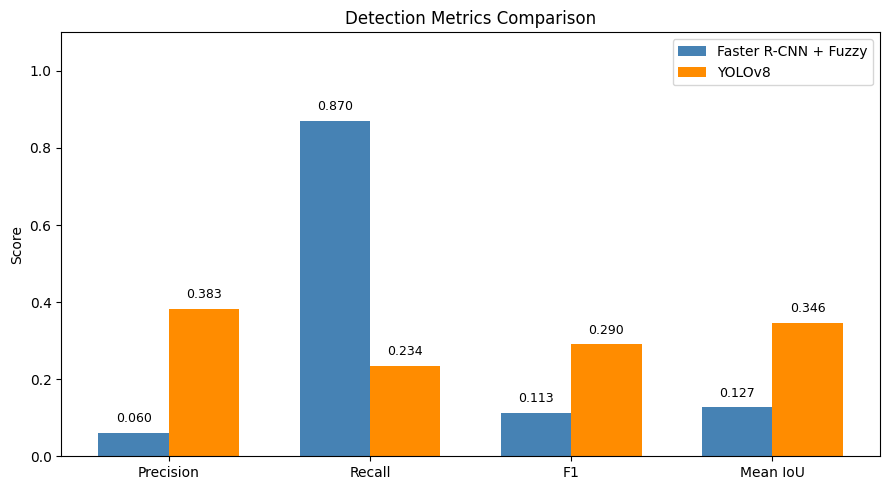

In [ ]:
metrics  = ['Precision', 'Recall', 'F1', 'Mean IoU']
rcnn_vals = [rcnn_prec, rcnn_rec, rcnn_f1, rcnn_miou]
yolo_vals = [yolo_prec, yolo_rec, yolo_f1, yolo_miou]

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(x - w/2, rcnn_vals, w, label='Faster R-CNN + Fuzzy', color='steelblue')
bars2 = ax.bar(x + w/2, yolo_vals, w, label='YOLOv8',               color='darkorange')

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Detection Metrics Comparison')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bar_metrics.png'), dpi=150)
plt.show()

/tmp/ipykernel_2920/1526934655.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


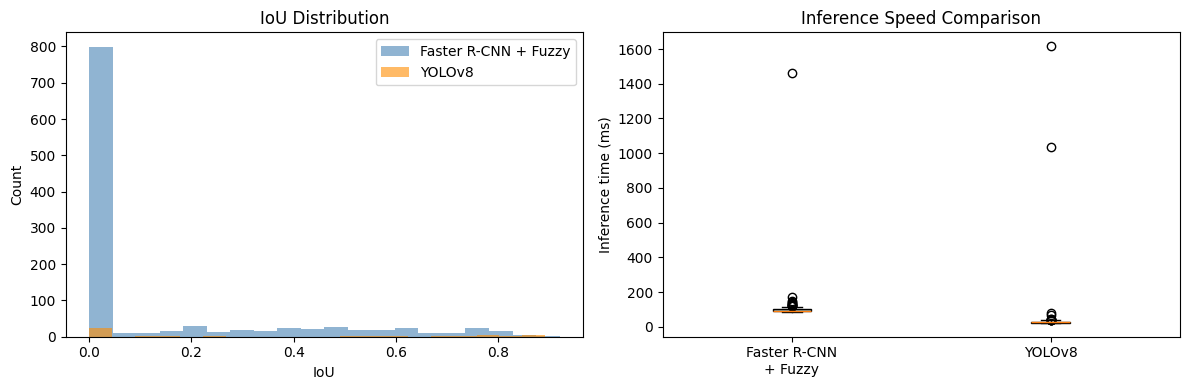

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# IoU histogram
axes[0].hist(rcnn_ious_all, bins=20, alpha=0.6, color='steelblue',  label='Faster R-CNN + Fuzzy')
axes[0].hist(yolo_ious_all, bins=20, alpha=0.6, color='darkorange', label='YOLOv8')
axes[0].set_xlabel('IoU'); axes[0].set_ylabel('Count')
axes[0].set_title('IoU Distribution')
axes[0].legend()

# Inference time boxplot
axes[1].boxplot(
    [np.array(rcnn_times)*1000, np.array(yolo_times)*1000],
    labels=['Faster R-CNN\n+ Fuzzy', 'YOLOv8'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[1].set_ylabel('Inference time (ms)')
axes[1].set_title('Inference Speed Comparison')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'iou_and_speed.png'), dpi=150)
plt.show()

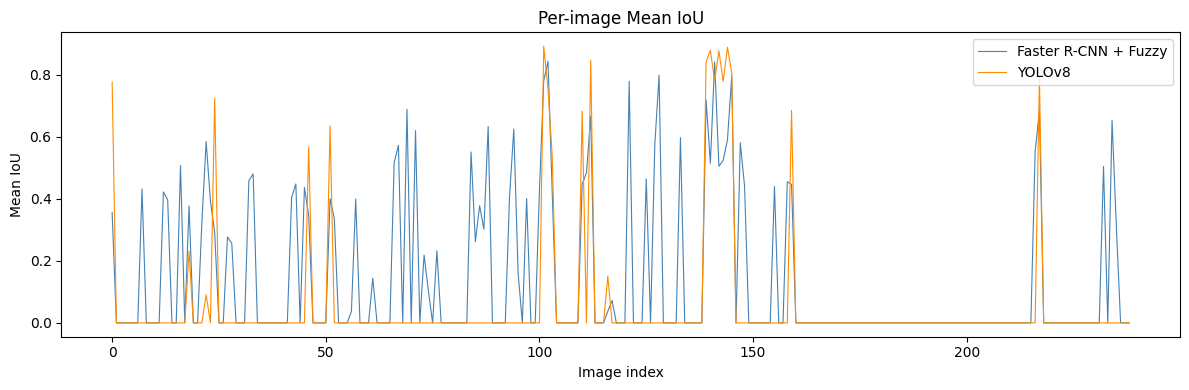

In [ ]:
df_records = pd.DataFrame(records)

plt.figure(figsize=(12, 4))
x = range(len(df_records))
plt.plot(x, df_records['rcnn_mean_iou'], color='steelblue',  label='Faster R-CNN + Fuzzy', linewidth=0.8)
plt.plot(x, df_records['yolo_mean_iou'], color='darkorange', label='YOLOv8',               linewidth=0.8)
plt.xlabel('Image index')
plt.ylabel('Mean IoU')
plt.title('Per-image Mean IoU')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_image_iou.png'), dpi=150)
plt.show()

In [ ]:
csv_path = os.path.join(RESULTS_DIR, 'per_image_results.csv')
df_records.to_csv(csv_path, index=False)
print(f'Per-image results saved to: {csv_path}')

summary_path = os.path.join(RESULTS_DIR, 'summary_metrics.csv')
df_summary.to_csv(summary_path, index=False)
print(f'Summary metrics saved to  : {summary_path}')

print('\n✅ All results saved to:', RESULTS_DIR)

Per-image results saved to: /content/drive/MyDrive/ROI_Endoscopy_Paper/comparison_results/per_image_results.csv
Summary metrics saved to  : /content/drive/MyDrive/ROI_Endoscopy_Paper/comparison_results/summary_metrics.csv

✅ All results saved to: /content/drive/MyDrive/ROI_Endoscopy_Paper/comparison_results


In [ ]:
print('\n' + '='*60)
print('ANALYSIS')
print('='*60)

if rcnn_f1 > yolo_f1:
    print(f'Faster R-CNN + Fuzzy has higher F1 ({rcnn_f1:.4f} vs {yolo_f1:.4f})')
else:
    print(f'YOLOv8 has higher F1 ({yolo_f1:.4f} vs {rcnn_f1:.4f})')

if yolo_fps > rcnn_fps:
    speedup = yolo_fps / rcnn_fps
    print(f'YOLOv8 is {speedup:.1f}x faster ({yolo_fps:.1f} FPS vs {rcnn_fps:.1f} FPS)')
else:
    speedup = rcnn_fps / yolo_fps
    print(f'Faster R-CNN is {speedup:.1f}x faster ({rcnn_fps:.1f} FPS vs {yolo_fps:.1f} FPS)')

if rcnn_miou > yolo_miou:
    print(f'Faster R-CNN + Fuzzy has better mean IoU ({rcnn_miou:.4f} vs {yolo_miou:.4f})')
else:
    print(f'YOLOv8 has better mean IoU ({yolo_miou:.4f} vs {rcnn_miou:.4f})')

print('='*60)


ANALYSIS
YOLOv8 has higher F1 (0.2903 vs 0.1131)
YOLOv8 is 2.6x faster (25.6 FPS vs 9.8 FPS)
YOLOv8 has better mean IoU (0.3464 vs 0.1268)
